# ***RANDOM FOREST***

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import time
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

## 1- Separación train-test

In [ ]:
y = df["readmitted"]
X = df.drop(columns=["readmitted"])

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

## 2- Random Forest con configuración por defecto

In [9]:
# Crear el modelo
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

# Entrenar
rf.fit(X_train, y_train)

# Predicciones
y_pred = rf.predict(X_test)

# Métricas
oob = rf.oob_score_
accuracy = accuracy_score(y_test, y_pred)

# Como readmitted es multiclase, usamos average='macro'
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Crear la tabla 
df_resultados = pd.DataFrame({
    "Configuración": ["RF por defecto (n=100)"],
    "OOB Score": [round(oob, 4)],
    "Test Accuracy": [round(accuracy, 4)],
    "Precision Macro": [round(precision, 4)],
    "Recall Macro": [round(recall, 4)],
    "F1-Score Macro": [round(f1, 4)]
})

display(df_resultados)

,Configuración,OOB Score,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,RF por defecto (n=100),0.5892,0.5958,0.5529,0.424,0.404


En primer lugar, se entrena un modelo Random Forest con la configuración por defecto, usando 100 árboles, para tener una primera referencia.

Los resultados muestran que el modelo obtiene un OOB Score de 0.5892 y una accuracy en test de 0.5958. Ambos valores son bastante parecidos, lo cual indica que el rendimiento estimado durante el entrenamiento y el obtenido en el conjunto de prueba son coherentes. Aun así, una accuracy cercana al 60% no es especialmente alta, sobre todo teniendo en cuenta que estamos trabajando con un problema sanitario donde los errores pueden tener consecuencias importantes.

Sin embargo, en este caso la accuracy por sí sola no es demasiado informativa. El objetivo no es simplemente acertar muchos casos en general, sino detectar correctamente los distintos tipos de readmisión hospitalaria, en especial aquellos que suceden antes de 30 días. Por eso son más informativas el resto de métricas. Aquí se observa que la precisión es de 0.5529, el recall baja a 0.424 y el F1-score se queda en 0.404, lo que indica que el modelo no está funcionando igual de bien para todas las clases.

El valor más preocupante es el recall, porque indica que el modelo está dejando sin identificar una parte importante de los casos de algunas clases. En el contexto del dataset de diabetes, esto es relevante porque la clase más importantes es la de pacientes readmitidos en menos de 30 días. Por lo tanto, si el modelo no detecta bien estos casos, no serviría como sistema de apoyo clínico, porque el objetivo principal es identificar estos casos para que no se les dé el alta de forma errónea.

El F1-score de 0.404 confirma esto, ya que aunque el modelo consigue una accuracy moderada, su rendimiento global entre clases es más limitado. Esto probablemente se debe al desbalanceo de clases, que es uno de los principales problemas encontrados en este dataset y que se tratarán el proyecto.

En resumen, este primer Random Forest sirve como una referencia inicial, pero los resultados muestran que el problema no se resuelve correctamente con la configuración por defecto. De forma que el modelo parece captar ciertos patrones generales, pero todavía tiene dificultades para reconocer correctamente todas las clases, especialmente las menos representadas, lo cual supone una limitación importante en este problema, porque no interesa solo acertar la clase más frecuente, sino identificar bien a los pacientes con mayor riesgo.

## 3- Grid Search

In [3]:
# Configuración
seed = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

# Grid de hiperparámetros
param_grid = {
    "n_estimators": [100, 150, 200, 300],
    "max_features": ["sqrt", "log2", 0.5, None],
    "max_depth": [None, 10, 20, 30],
    "min_samples_leaf": [1, 2, 5, 10]
}

# Grid Search
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=seed,
        n_jobs=-1,
        oob_score=True,
        bootstrap=True
    ),
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",   # mejor que accuracy para clases desbalanceadas
    n_jobs=-1,
    return_train_score=False
)

grid_rf.fit(X_train, y_train)

# Resultados del Grid Search
cv_results = pd.DataFrame(grid_rf.cv_results_)

results_df = cv_results[[
    "param_n_estimators",
    "param_max_features",
    "param_max_depth",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# Ordenar por ranking
results_df = results_df.sort_values(
    by=["rank_test_score", "mean_test_score"],
    ascending=[True, False]
).reset_index(drop=True)

# Top 10 configuraciones
top_results = results_df.head(10).copy()

# Calcular métricas adicionales en test y OOB
test_accuracy = []
precision_macro = []
recall_macro = []
f1_macro = []
oob_scores = []

for _, row in top_results.iterrows():

    max_depth_value = row["param_max_depth"]
    if pd.isna(max_depth_value) or max_depth_value == "None":
        max_depth_value = None
    else:
        max_depth_value = int(max_depth_value)

    max_features_value = row["param_max_features"]
    if pd.isna(max_features_value) or max_features_value == "None":
        max_features_value = None

    rf = RandomForestClassifier(
        random_state=seed,
        n_jobs=-1,
        oob_score=True,
        bootstrap=True,
        n_estimators=int(row["param_n_estimators"]),
        max_features=max_features_value,
        max_depth=max_depth_value,
        min_samples_leaf=int(row["param_min_samples_leaf"])
    )

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    test_accuracy.append(round(accuracy_score(y_test, y_pred), 4))
    precision_macro.append(round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4))
    recall_macro.append(round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4))
    f1_macro.append(round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4))
    oob_scores.append(round(rf.oob_score_, 4))

# Renombrar columnas para que la tabla quede más clara
top_results = top_results.rename(columns={
    "param_n_estimators": "n_estimators",
    "param_max_features": "max_features",
    "param_max_depth": "max_depth",
    "param_min_samples_leaf": "min_samples_leaf",
    "mean_test_score": "CV F1 Macro",
    "std_test_score": "CV Std",
    "rank_test_score": "Ranking"
})

# Añadir métricas
top_results["OOB Score"] = oob_scores
top_results["Test Accuracy"] = test_accuracy
top_results["Precision Macro"] = precision_macro
top_results["Recall Macro"] = recall_macro
top_results["F1-Score Macro"] = f1_macro

# Redondear columnas numéricas
top_results["CV F1 Macro"] = top_results["CV F1 Macro"].round(4)
top_results["CV Std"] = top_results["CV Std"].round(4)

# Reordenar columnas
top_results = top_results[[
    "Ranking",
    "n_estimators",
    "max_features",
    "max_depth",
    "min_samples_leaf",
    "CV F1 Macro",
    "CV Std",
    "OOB Score",
    "Test Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1-Score Macro"
]]

display(top_results)

print("Mejores parámetros encontrados:")
print(grid_rf.best_params_)

print(f"\nMejor F1 Macro en validación cruzada: {grid_rf.best_score_:.4f}")

,Ranking,n_estimators,max_features,max_depth,min_samples_leaf,CV F1 Macro,CV Std,OOB Score,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,1,300,None,30,1,0.4267,0.0016,0.5948,0.5955,0.5399,0.4385,0.4301
1,2,300,None,20,1,0.4265,0.0017,0.5960,0.5976,0.5432,0.4390,0.4293
2,3,200,None,20,1,0.4265,0.0030,0.5939,0.5977,0.5482,0.4404,0.4316
3,4,300,None,30,2,0.4263,0.0022,0.5961,0.5982,0.5445,0.4394,0.4298
4,5,300,None,None,1,0.4260,0.0021,0.5950,0.5944,0.5353,0.4369,0.4278
5,6,150,None,20,1,0.4258,0.0022,0.5923,0.5951,0.5439,0.4380,0.4288
6,7,300,None,20,2,0.4255,0.0021,0.5983,0.5985,0.5449,0.4390,0.4284
7,8,200,None,20,2,0.4255,0.0026,0.5960,0.6003,0.5449,0.4408,0.4305
8,9,200,None,30,1,0.4254,0.0018,0.5920,0.5963,0.5417,0.4398,0.4320
9,10,150,None,20,2,0.4254,0.0019,0.5948,0.5984,0.5445,0.4395,0.4296


Mejores parámetros encontrados:
{'max_depth': 30, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 300}

Mejor F1 Macro en validación cruzada: 0.4267


En este apartado se ha hecho una búsqueda de hiperparámetros para comprobar si el modelo podía mejorar ajustándose o su rendimiento era limitado en cualquier caso. En este caso, el mejor resultado se obtiene con 300 árboles, una profundidad máxima de 30, usando todas las variables disponibles y permitiendo hojas con una sola muestra. Con esta configuración, el modelo alcanza un F1 de 0.4267 en validación cruzada y un F1 de 0.4301 en test.

Lo primero que se puede observar es que hay una mejora con respecto al modelo por defecto, pero es pequeña. El Random Forest inicial tenía un F1 macro de 0.404, mientras que después del ajuste sube aproximadamente a 0.43. Esto indica que el modelo mejora algo al elegir mejor sus parámetros, pero también deja claro que el problema no se soluciona simplemente aumentando el número de árboles o modificando la profundidad. En el contexto del problema, esto tiene sentido, porque predecir si un paciente diabético va a volver a ingresar no depende de una única variable, sino de varios factores que se combinan entre sí. 

La accuracy se mantiene alrededor de 0.60, prácticamente igual que en el modelo anterior. Sin embargo, la accuracy no es la métrica más importante en este caso, ya que una de las problemáticas principales del proyecto es el desbalanceo de clases, por lo tanto, el modelo puede conseguir una accuracy buena acertando sobre todo la clase mayoritaria. Por ejemplo, si hay muchos más pacientes que no reingresan que pacientes que sí reingresan en menos de 30 días, el modelo puede parecer útil simplemente porque predice bien los casos más frecuentes. El problema es que, en este problema la clase minoritaria es la de pacientes readmitidos antes de 30 días, que justamente es la clase que más interesa detectar correctamente.

El recall del mejor modelo está alrededor de 0.4385, lo que sigue siendo bajo. Es decir, el modelo todavía no detecta bien todas las clases, especialmente aquellas con menos ejemplos. Como ya se ha explicado, en el contexto del problema, esto es una limitación importante, porque si el sistema no identifica correctamente a pacientes con riesgo de readmisión temprana, se perdería la oportunidad de hacer un seguimiento más estrecho y planificar mejor el alta.

La precisión se sitúa en torno a 0.54. Esto indica que, cuando el modelo predice una clase, sus predicciones tienen una fiabilidad moderada, pero no suficientemente alta como para confiar en ellas sin más. En un contexto clínico esto es importante, porque una predicción errónea tiene consecuencias graves, ya que puede afectar a cómo se organizan los recursos del hospital y a la salud de los pacientes.

También es relevante que las diez mejores configuraciones tienen resultados muy parecidos entre sí. El F1 macro en validación cruzada apenas cambia entre unas y otras, moviéndose alrededor de 0.425–0.427. Esto sugiere que el Random Forest ha llegado a un límite, de forma que cambiar los hiperparámetros, no produce una mejora clara. Por lo que la dificultad principal no está solo en los hiperparámetros, sino en las propias características y problemáticas del dataset.

Los resultados también refuerzan la necesidad de aplicar explicabilidad. Un F1 macro de aproximadamente 0.43 no es suficiente para usar el modelo como una herramienta automática de decisión, pero incluso aunque el rendimiento fuera mayor, en sanidad no bastaría con obtener una predicción. Sería necesario saber por qué el modelo considera que un paciente tiene riesgo de readmisión. 

En conjunto, la búsqueda de hiperparámetros muestra que el Random Forest ajustado mejora ligeramente al modelo inicial, pero no obtiene unos resultados lo suficientemente buenos como para ser utilizado directamente en un contexto sanitario, lo que refuerza la importancia de tratar las diferentes problemáticas. 

## 4- Importancia de características

In [ ]:
# Mejor modelo obtenido en el Grid Search
best_rf = rf = RandomForestClassifier(
        random_state=seed,
        n_jobs=-1,
        oob_score=True,
        bootstrap=True,
        n_estimators=300,
        max_features=None,
        max_depth=30,
        min_samples_leaf=1
    )

# Entrenar el mejor modelo
best_rf.fit(X_train, y_train)

# Predicciones del mejor modelo
y_pred = best_rf.predict(X_test)

# Gini Importance
importances_gini = best_rf.feature_importances_

# Permutation Importance
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="f1_macro"
)

# Ordenar por importancia Gini
indices = np.argsort(importances_gini)[::-1]

# Nombres de las variables
feature_names = X_train.columns

# Guardar resultados
resultados = []

for rank, idx in enumerate(indices):
    resultados.append({
        "Ranking": rank + 1,
        "Feature": feature_names[idx],
        "Gini Importance": round(importances_gini[idx], 4),
        "Permutation Importance": round(perm.importances_mean[idx], 4),
        "Permutation Std": round(perm.importances_std[idx], 4)
    })

# Crear DataFrame
df_importance = pd.DataFrame(resultados)

# Mostrar resultados
display(df_importance)

,Ranking,Feature,Gini Importance,Permutation Importance,Permutation Std
0,1,encounter_id,0.1184,0.0221,0.0016
1,2,patient_nbr,0.1122,0.0299,0.0020
2,3,num_lab_procedures,0.0760,0.0017,0.0014
3,4,diag_1,0.0734,0.0030,0.0016
4,5,diag_2,0.0720,0.0017,0.0014
5,6,diag_3,0.0699,0.0024,0.0013
6,7,num_medications,0.0659,0.0027,0.0010
7,8,time_in_hospital,0.0441,-0.0000,0.0011
8,9,number_inpatient,0.0404,0.0400,0.0013
9,10,discharge_disposition_id,0.0386,0.0176,0.0019


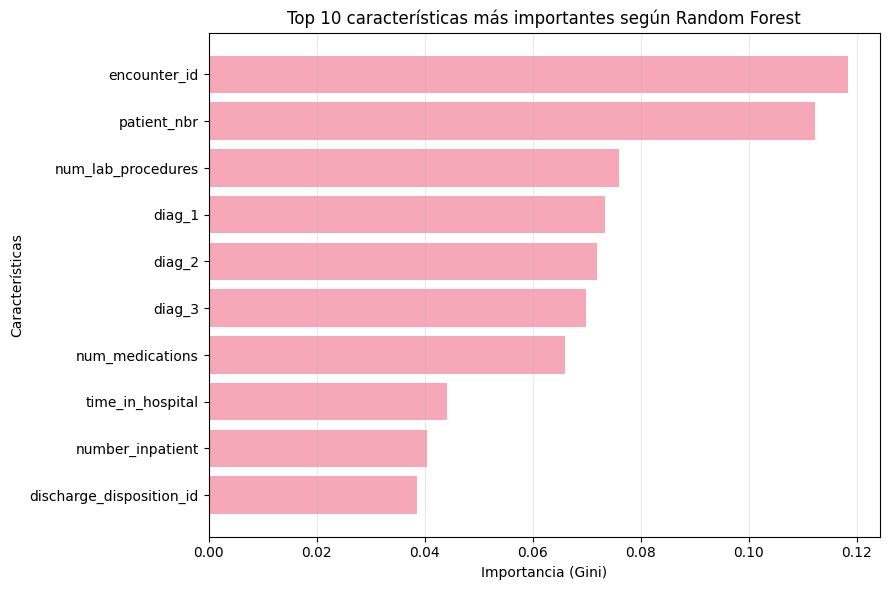

In [ ]:
# Número de características a mostrar
top_n = 10
top_features = df_importance.head(top_n)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Gini Importance"][::-1],
    color="#F7A8B8"  # rosa pastel
)

plt.xlabel("Importancia (Gini)")
plt.ylabel("Características")
plt.title("Top 10 características más importantes según Random Forest")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../visualizacion_random_forest/rf_gini_importance_top10.png", dpi=300, bbox_inches="tight")
plt.show()

Para entender mejor cómo está tomando decisiones el modelo, se ha analizado la importancia de las características. Esto permite ver qué variables está utilizando más el modelo para predecir si un paciente diabético puede volver a ingresar en el hospital. Este análisis es importante porque, en un contexto sanitario, no basta con saber si el modelo acierta más o menos, también hay que entender en qué se está basando para hacer sus predicciones, lo cual se relaciona con una de las principales problemáticas del dataset, concretamente la explicabilidad.

En los resultados, las dos variables que aparecen como más importantes son **"encounter_id"** y **"patient_nbr"**. Esto llama la atención porque no son variables clínicas, sino identificadores. Por tanto, aunque el modelo les dé mucha importancia, no significa que tengan una explicación médica como tal. Esto puede ser problemático, porque el modelo podría estar aprendiendo patrones asociados a pacientes concretos, en lugar de aprender relaciones generales en base a la información médica que sirvan para nuevos pacientes.

Después de estos identificadores, aparecen variables que sí tienen más sentido dentro del contexto médico, como **"num_lab_procedures"**, **"diag_1"**, **"diag_2"**, **"diag_3"**, **"num_medications"**, **"time_in_hospital"**, **"number_inpatient"** y **"discharge_disposition_id"**. Estas variables están relacionadas con el estado del paciente, la complejidad del ingreso y su historial hospitalario, por lo que es lógico y positivo que el modelo las utilice para intentar predecir la readmisión.

Por ejemplo, **"num_lab_procedures"** indica cuántas pruebas de laboratorio se le realizaron al paciente. De forma que si un paciente necesita muchas pruebas, puede ser señal de que su caso es más complejo y con ello, puede estar relacionado con un mayor riesgo de volver al hospital. Algo parecido ocurre con **"num_medications"**, ya que un paciente con más medicamentos puede tener un tratamiento más complejo o más enfermedades asociadas.

Las variables de diagnóstico, como **"diag_1"**, **"diag_2"** y **"diag_3"**, también aparecen entre las más importantes. Esto tiene sentido, porque el riesgo de readmisión no depende solo de que el paciente tenga diabetes, sino también de otros problemas de salud que pueda tener. Un paciente diabético con otras enfermedades puede tener un riesgo distinto y probablemente mayor al de otro paciente con una situación más estable.

También destaca **"time_in_hospital"**, que representa el tiempo que el paciente estuvo ingresado. Una estancia más larga puede indicar que el caso fue más grave o que el paciente necesitó más control. Por eso es razonable que el modelo tenga en cuenta esta variable.  Otra variable importante es **"number_inpatient"**, que recoge ingresos hospitalarios previos, lo que tiene mucho sentido dentro del problema, porque un paciente que ya ha ingresado anteriormente puede tener una situación de salud más inestable o una enfermedad más difícil de controlar. Por tanto, es lógico que el historial previo de ingresos ayude al modelo a estimar el riesgo de un nuevo reingreso.

También aparece **"discharge_disposition_id"**, que indica la situación del paciente al recibir el alta. Esta variable puede ser muy relevante, porque no es lo mismo que un paciente vuelva directamente a casa a que necesite otro tipo de cuidados. El estado del paciente en el momento del alta puede influir bastante en la probabilidad de que vuelva a ingresar.

En la gráfica se ve esta información de forma más clara. Las barras muestran que **"encounter_id"** y **"patient_nbr"** están bastante por encima del resto de variables, por lo que hay que tener cuidado. Después, las siguientes variables más importantes ya son más interpretables desde el punto de vista clínico, lo que demuestra que el modelo sí está utilizando información médica relevante.

## 5- Extra Trees

In [8]:
# Crear modelo
et = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Entrenar
et.fit(X_train, y_train)

# Predicciones
y_pred = et.predict(X_test)

# Validación cruzada usando F1 macro
cv_et = cross_val_score(
    et,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# Métricas
cv_mean = cv_et.mean()
cv_std = cv_et.std()
test_acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

# Crear tabla
df_et = pd.DataFrame({
    "Modelo": ["Extra Trees (n=100)"],
    "CV F1 Macro": [round(cv_mean, 4)],
    "CV Std": [round(cv_std, 4)],
    "Test Accuracy": [round(test_acc, 4)],
    "Precision Macro": [round(precision, 4)],
    "Recall Macro": [round(recall, 4)],
    "F1-Score Macro": [round(f1, 4)]
})

display(df_et)

,Modelo,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro
0,Extra Trees (n=100),0.3966,0.004,0.5863,0.5209,0.4149,0.3958


El modelo Extra Trees es un método parecido al Random Forest, ya que también construye muchos árboles de decisión y combina sus predicciones para obtener un resultado final. La diferencia es que introduce todavía más aleatoriedad durante el entrenamiento, porque elige las divisiones de forma más aleatoria. 

En este caso, el modelo obtiene una accuracy en test de 0.5863, un valor ligeramente inferior al obtenido con Random Forest. Esto indica que, en términos generales, el modelo acierta algo menos el conjunto total de pacientes. Aun así, ya se ha explicado que la accuracy no debe interpretarse como la métrica principal, porque el dataset presenta desbalanceo entre clases. 

Si nos fijamos en el F1 macro, el resultado es de 0.3958 en test, también por debajo del Random Forest. Esto indica que Extra Trees está teniendo más dificultades para equilibrar el rendimiento entre las distintas clases. En el contexto del problema, este resultado es importante porque la predicción de readmisión no debería centrarse solo en acertar los casos más comunes.

El recall es de 0.4149, lo que muestra que el modelo no está detectando correctamente una parte considerable de los casos reales de cada clase. Este punto es relevante, ya que si un paciente tiene riesgo de readmisión temprana y el modelo no lo identifica, se pierde una posible oportunidad de actuar correctamente protegiendo la salud del paciente. 

La precisión macro es de 0.5209, lo que significa que las predicciones del modelo tienen una fiabilidad moderada, pero tampoco especialmente alta. Esto puede generar dos tipos de problemas. Por un lado, puede señalar como pacientes de riesgo a personas que realmente no van a reingresar, usando recursos hospitalarios innecesarios, y por otro lado, puede no identificar a pacientes que sí deberían ser vigilados más de cerca.

También se observa que el F1 macro en validación cruzada es de 0.3966, muy parecido al resultado en test. Esto es positivo en el sentido de que el modelo se comporta de forma estable. La desviación estándar de 0.004 también es baja, por lo que el rendimiento no cambia demasiado entre particiones. Sin embargo, esa estabilidad no significa que el modelo sea bueno, sino que mantiene un rendimiento limitado de forma consistente.

Por lo tanto, aquí la mayor aleatoriedad del modelo parece perjudicar el rendimiento, lo que puede deberse a que la readmisión hospitalaria depende de características clínicas, y si las divisiones de los árboles son demasiado aleatorias, el modelo puede no captar bien las relaciones importantes entre las variables. 

## 6- Evaluación final

In [9]:
resultados = []
# Random Forest por defecto

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf.fit(X_train, y_train)

cv_rf = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

y_pred_rf = rf.predict(X_test)

resultados.append({
    "Modelo": "Random Forest por defecto",
    "CV F1 Macro": round(cv_rf.mean(), 4),
    "CV Std": round(cv_rf.std(), 4),
    "Test Accuracy": round(accuracy_score(y_test, y_pred_rf), 4),
    "Precision Macro": round(precision_score(y_test, y_pred_rf, average="macro", zero_division=0), 4),
    "Recall Macro": round(recall_score(y_test, y_pred_rf, average="macro", zero_division=0), 4),
    "F1-Score Macro": round(f1_score(y_test, y_pred_rf, average="macro", zero_division=0), 4),
    "OOB Score": round(rf.oob_score_, 4)
})


# Random Forest mejor config
best_rf = rf = RandomForestClassifier(
        random_state=seed,
        n_jobs=-1,
        oob_score=True,
        bootstrap=True,
        n_estimators=300,
        max_features=None,
        max_depth=30,
        min_samples_leaf=1
    )
best_rf.fit(X_train, y_train)


cv_best = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

y_pred_best = best_rf.predict(X_test)

resultados.append({
    "Modelo": "Random Forest mejor config",
    "CV F1 Macro": round(cv_best.mean(), 4),
    "CV Std": round(cv_best.std(), 4),
    "Test Accuracy": round(accuracy_score(y_test, y_pred_best), 4),
    "Precision Macro": round(precision_score(y_test, y_pred_best, average="macro", zero_division=0), 4),
    "Recall Macro": round(recall_score(y_test, y_pred_best, average="macro", zero_division=0), 4),
    "F1-Score Macro": round(f1_score(y_test, y_pred_best, average="macro", zero_division=0), 4),
    "OOB Score": round(best_rf.oob_score_, 4) if hasattr(best_rf, "oob_score_") else None
})


# Extra Trees
et = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

cv_et = cross_val_score(
    et,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

y_pred_et = et.predict(X_test)

resultados.append({
    "Modelo": "Extra Trees",
    "CV F1 Macro": round(cv_et.mean(), 4),
    "CV Std": round(cv_et.std(), 4),
    "Test Accuracy": round(accuracy_score(y_test, y_pred_et), 4),
    "Precision Macro": round(precision_score(y_test, y_pred_et, average="macro", zero_division=0), 4),
    "Recall Macro": round(recall_score(y_test, y_pred_et, average="macro", zero_division=0), 4),
    "F1-Score Macro": round(f1_score(y_test, y_pred_et, average="macro", zero_division=0), 4),
    "OOB Score": None
})


# Tabla final
df_final = pd.DataFrame(resultados)
display(df_final)

,Modelo,CV F1 Macro,CV Std,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,OOB Score
0,Random Forest por defecto,0.4048,0.0033,0.5958,0.5529,0.4240,0.4040,0.5892
1,Random Forest mejor config,0.4260,0.0047,0.5955,0.5399,0.4385,0.4301,0.5948
2,Extra Trees,0.3966,0.0040,0.5863,0.5209,0.4149,0.3958,NaN


Una vez entrenados los diferentes modelos, se puede hacer una comparación más clara para decidir cuál puede servir como mejor candidato a modelo baseline dentro del proyecto y así compararlo con modelos de otras familias.

El primer punto importante es que los tres modelos tienen una accuracy bastante parecida, alrededor de 0.58–0.59. El Random Forest por defecto obtiene una accuracy de 0.5958, el Random Forest ajustado obtiene 0.5955 y Extra Trees baja hasta 0.5863. Sin embargo, como ya se ha ido explicando, en este problema la accuracy no es suficiente para decidir qué modelo es mejor debido al problema del desbalanceo de clases que hace que esta métrica obtenga resultados que pueden ser engañosos.

Por este motivo, para elegir el modelo baseline se ha decidido dar más importancia al F1-score. Esta métrica resulta más adecuada para este problema porque combina precisión y recall, es decir, tiene en cuenta tanto si el modelo acierta cuando predice una clase como si es capaz de detectar correctamente los casos reales de esa clase. Esto es importante porque no interesa un modelo que solo sea bueno en una de las dos cosas. En un problema como este, un modelo con mucha precisión pero poco recall podría detectar pocos pacientes de riesgo, mientras que un modelo con mucho recall pero poca precisión podría marcar demasiados pacientes como posibles reingresos.

Al comparar los resultados, el mejor modelo según F1-score es el Random Forest con la mejor configuración, que obtiene un valor de 0.4301 en test. Este resultado supera al Random Forest por defecto, que obtiene 0.4040, y también a Extra Trees, que obtiene 0.3958. Aunque la mejora no es muy grande, sí es relevante porque indica que el modelo ajustado consigue un mejor equilibrio entre precisión y recall. Es decir, no solo acierta más casos en general, sino que mejora ligeramente su capacidad para tratar las diferentes clases de forma más compensada, lo cual es imporante en este contexto de desbalanceo.

El Random Forest por defecto tiene una precisión algo superior, con un valor de 0.5529, frente al 0.5399 del Random Forest ajustado. Sin embargo, su recall es menor, 0.4240 frente a 0.4385. Por lo tanto, el modelo por defecto parece ser más preciso cuando predice ciertas clases, pero detecta menos casos reales. En el contexto del problema, esto puede ser una limitación importante, porque si el modelo no identifica a pacientes que realmente van a ser readmitidos de forma temprana, se pierde el objetivo principal del sistema.

En cambio, el Random Forest ajustado baja ligeramente precisión, pero mejora el recall. Esto hace que su F1-score sea el mejor. Esta decisión tiene sentido, porque el objetivo no es únicamente que las predicciones sean correctas cuando el modelo clasifica un caso, sino que también sea capaz de detectar una mayor proporción de pacientes pertenecientes a cada clase. En sanidad, este equilibrio es fundamental, ya que tanto los falsos positivos como los falsos negativos tienen consecuencias, unos pueden suponer uso innecesario de recursos, y otros pueden implicar no detectar a pacientes con riesgo de volver al hospital.

Extra Trees es el modelo que peores resultados obtiene en la comparación. Esto indica que, para este dataset, añadir más aleatoriedad en la construcción de los árboles no ha ayudado. Esto puede deberse a que el problema ya es complejo de por sí, con variables clínicas  y factores médicos que no siempre tienen una relación directa y sencilla con la readmisión.

También es importante fijarse en la validación cruzada. El Random Forest ajustado obtiene un CV F1 de 0.4260 y un F1-score macro en test de 0.4301, valores bastante cercanos, lo que indica que el rendimiento del modelo es estable, como ya se ha comentado. 

Por todo ello, el modelo elegido como candidato a baseline será el Random Forest con la mejor configuración, ya que es el que obtiene el mayor F1-score. Aun así, su resultado sigue siendo bajo para un posible uso real en un entorno sanitario, ya que se ve que el modelo tiene dificultades para diferenciar correctamente los distintos tipos de readmisión. Por tanto, será necesario compararlo con modelos de otras familias y aplicar técnicas para tratar las problemáticas del proyecto.